In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv("data/AAPL.csv")

print(df.shape)
print(df.head())

print(df.columns.tolist())
print(df.head())

(9909, 7)
         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400


In [11]:
# convert Date column to actual dates so we can plot properly
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

print("earliest date:", df['Date'].min())
print("latest date:", df['Date'].max())
print("total trading days:", len(df))

earliest date: 1980-12-12 00:00:00
latest date: 2020-04-01 00:00:00
total trading days: 9909


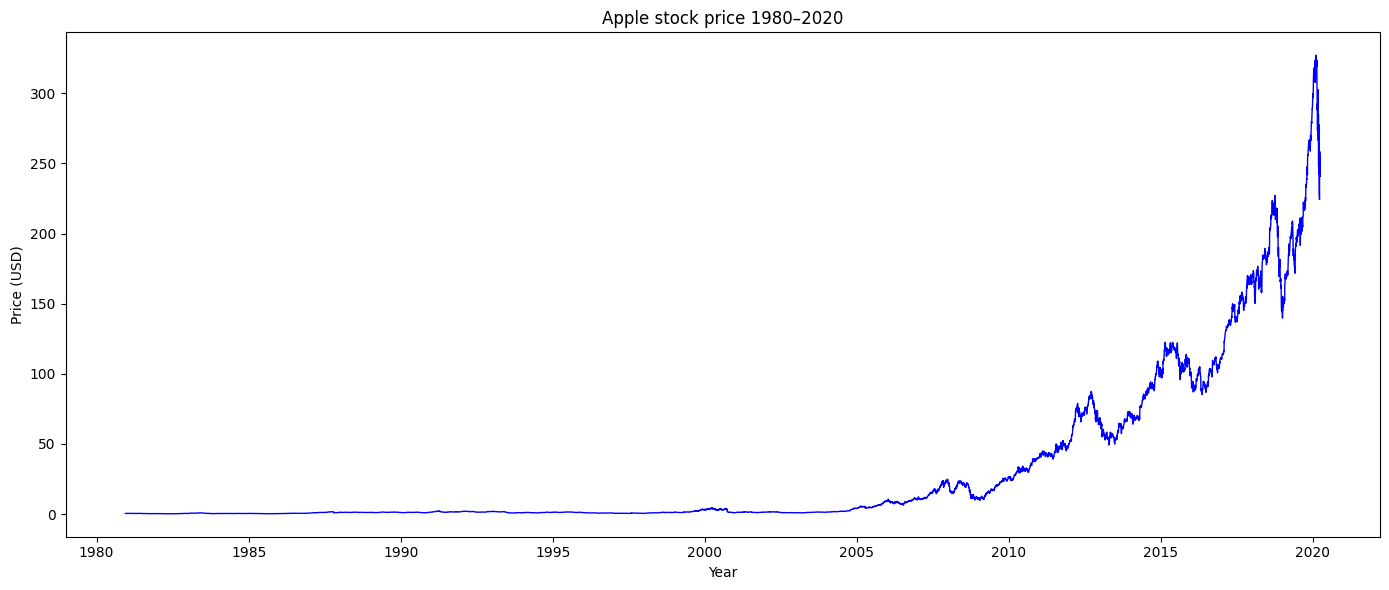

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Adj Close'], color='blue', linewidth=1)
plt.title("Apple stock price 1980–2020")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("apple_price_history.png")
plt.show()

In [13]:
# daily volatility = how much price moved as a percentage of open price
df['volatility'] = ((df['High'] - df['Low']) / df['Open']) * 100

# top 10 most volatile days
top_volatile = df.nlargest(10, 'volatility')[['Date', 'Open', 'High', 'Low', 'volatility']]
print("Top 10 most volatile days:")
print(top_volatile.to_string(index=False))

Top 10 most volatile days:
      Date      Open       High       Low  volatility
1998-01-06  0.569196   0.714286  0.526786   32.941178
1987-10-19  1.723214   1.723214  1.267857   26.424867
1987-10-20  1.375000   1.500000  1.165179   24.350652
2010-05-06 36.261429  36.892857 28.464285   23.243904
1987-10-29  1.223214   1.428571  1.151786   22.627739
1987-10-26  1.232143   1.250000  0.986607   21.376813
1998-01-02  0.486607   0.580357  0.482143   20.183483
2015-08-24 94.870003 108.800003 92.000000   17.708446
2008-10-10 12.242857  14.285714 12.142858   17.502913
1986-04-29  0.571429   0.575893  0.479911   16.796878


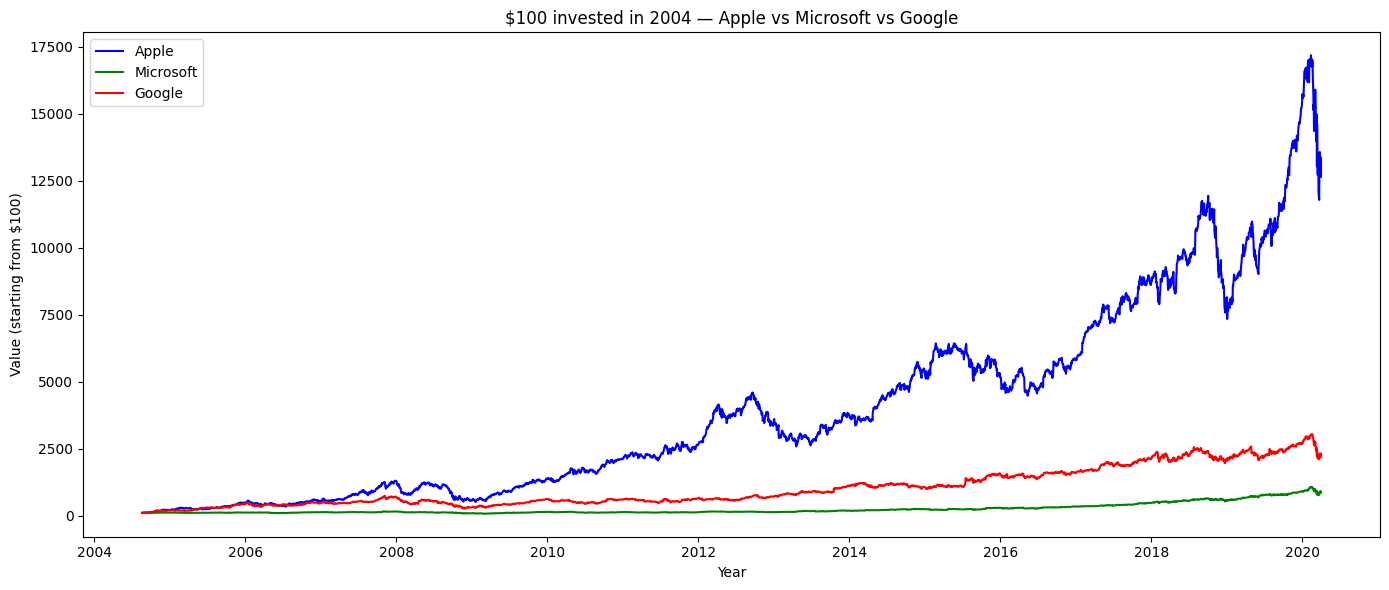

In [ ]:
# load Microsoft and Google too
msft = pd.read_csv("data/MSFT.csv")
googl = pd.read_csv("dataGOOGL.csv")

msft['Date'] = pd.to_datetime(msft['Date'])
googl['Date'] = pd.to_datetime(googl['Date'])

# only compare from 2004 onwards (when Google went public)
start_date = '2004-08-19'
aapl = df[df['Date'] >= start_date].copy()
msft = msft[msft['Date'] >= start_date].copy()
googl = googl[googl['Date'] >= start_date].copy()

# normalize to 100 so we can compare growth fairly
# this answers: if you invested $100 in each, what would it be worth today?
aapl['normalized'] = (aapl['Adj Close'] / aapl['Adj Close'].iloc[0]) * 100
msft['normalized'] = (msft['Adj Close'] / msft['Adj Close'].iloc[0]) * 100
googl['normalized'] = (googl['Adj Close'] / googl['Adj Close'].iloc[0]) * 100

plt.figure(figsize=(14, 6))
plt.plot(aapl['Date'], aapl['normalized'], label='Apple', color='blue')
plt.plot(msft['Date'], msft['normalized'], label='Microsoft', color='green')
plt.plot(googl['Date'], googl['normalized'], label='Google', color='red')
plt.title("$100 invested in 2004 — Apple vs Microsoft vs Google")
plt.xlabel("Year")
plt.ylabel("Value (starting from $100)")
plt.legend()
plt.tight_layout()
plt.savefig("comparison.png")
plt.show()